In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
data = pd.read_csv('./newfile.csv')
data.drop(['Unnamed: 0','id','Product ID'],axis=1,inplace=True) 

data

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power,RotationalSpeed_TorqueRatio,ToolWearRate,Temperature_Difference,Average_Temperature,Toolwear_Rate
0,L,300.6,309.6,1596,36.1,140,0,57615.6,44.210526,5054.0,9.0,305.10,0.553360
1,M,302.6,312.1,1759,29.1,200,0,51186.9,60.446735,5820.0,9.5,307.35,0.790514
2,L,299.3,308.5,1805,26.5,25,0,47832.5,68.113208,662.5,9.2,303.90,0.098814
3,L,301.0,310.9,1524,44.3,197,0,67513.2,34.401806,8727.1,9.9,305.95,0.778656
4,M,298.0,309.0,1641,35.4,34,0,58091.4,46.355932,1203.6,11.0,303.50,0.134387
...,...,...,...,...,...,...,...,...,...,...,...,...,...
136424,M,300.1,311.4,1530,37.5,210,0,57375.0,40.800000,7875.0,11.3,305.75,0.830040
136425,H,297.5,308.5,1447,49.1,2,0,71047.7,29.470468,98.2,11.0,303.00,0.007905
136426,L,300.5,311.8,1524,38.5,214,0,58674.0,39.584416,8239.0,11.3,306.15,0.845850
136427,L,301.7,310.9,1447,46.3,42,0,66996.1,31.252700,1944.6,9.2,306.30,0.166008


In [2]:

#train = data[["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "Machine failure"]]



target_0 = data[data['Machine failure'] == 0]
target_1 = data[data['Machine failure'] == 1]

sampled_failure_0 = target_0.sample(n=2000, random_state=42)
sampled_failure_1 = target_1.sample(n=2000, random_state=42)

renew_train = pd.concat([sampled_failure_1, sampled_failure_0])

renew_train

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power,RotationalSpeed_TorqueRatio,ToolWearRate,Temperature_Difference,Average_Temperature,Toolwear_Rate
73745,L,296.9,307.9,1371,57.1,204,1,78284.1,24.010508,11648.4,11.0,302.40,0.806324
127644,L,302.0,310.5,1358,50.3,177,1,68307.4,26.998012,8903.1,8.5,306.25,0.699605
61587,L,300.5,311.6,1486,58.4,189,1,86782.4,25.445205,11037.6,11.1,306.05,0.747036
49422,M,302.5,310.3,1368,51.9,134,1,70999.2,26.358382,6954.6,7.8,306.40,0.529644
56027,L,300.9,312.0,1335,57.2,168,1,76362.0,23.339161,9609.6,11.1,306.45,0.664032
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112639,M,300.7,309.5,1352,44.0,33,0,59488.0,30.727273,1452.0,8.8,305.10,0.130435
62760,L,303.9,312.9,1407,42.5,194,0,59797.5,33.105882,8245.0,9.0,308.40,0.766798
55065,M,300.5,310.4,1571,34.6,228,0,54356.6,45.404624,7888.8,9.9,305.45,0.901186
24656,L,298.9,308.6,1758,25.4,7,0,44653.2,69.212598,177.8,9.7,303.75,0.027668


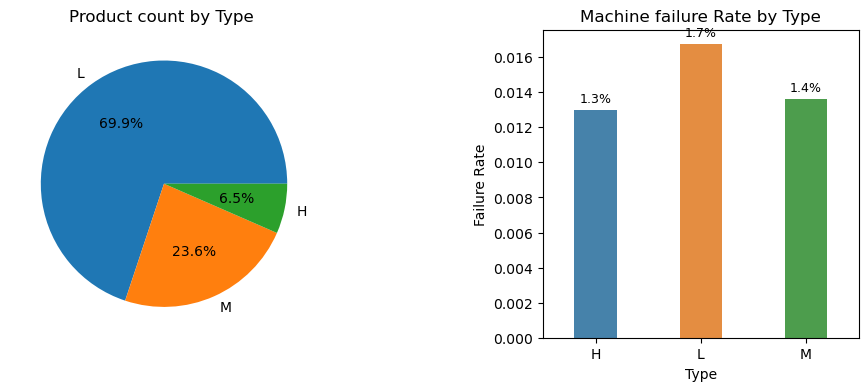

In [18]:
fig= plt.figure(figsize=(11,4))
type_count = data['Type'].value_counts()
ax1= plt.subplot(1,2,1)
ax1.pie(type_count.values, labels = type_count.index, autopct='%1.1f%%')
ax1.set_title("Product count by Type ")


ax2= plt.subplot(1,2,2)
type_failure_rate = data.groupby('Type')['Machine failure'].mean().reset_index()
sns.barplot(x='Type', y='Machine failure', data=type_failure_rate,  alpha= 0.9, width= 0.4, ax= ax2)
ax2.set_title('Machine failure Rate by Type')
ax2.set_ylabel('Failure Rate')
#ax2.set_ylim([0, 0.03])
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 8),
                textcoords='offset points')

plt.subplots_adjust(wspace=0.7)
plt.show()

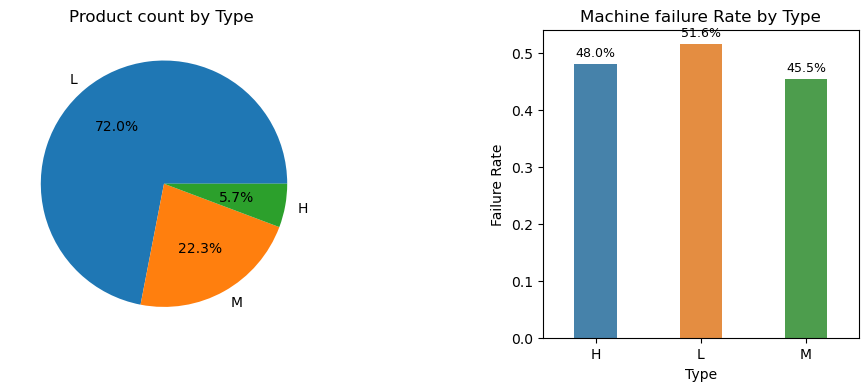

In [23]:
fig= plt.figure(figsize=(11,4))
type_count = renew_train['Type'].value_counts()
ax1= plt.subplot(1,2,1)
ax1.pie(type_count.values, labels = type_count.index, autopct='%1.1f%%')
ax1.set_title("Product count by Type ")


ax2= plt.subplot(1,2,2)
type_failure_rate = renew_train.groupby('Type')['Machine failure'].mean().reset_index()
sns.barplot(x='Type', y='Machine failure', data=type_failure_rate,  alpha= 0.9, width= 0.4, ax= ax2)
ax2.set_title('Machine failure Rate by Type')
ax2.set_ylabel('Failure Rate')
#ax2.set_ylim([0, 0.03])
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 8),
                textcoords='offset points')

plt.subplots_adjust(wspace=0.7)
plt.show()


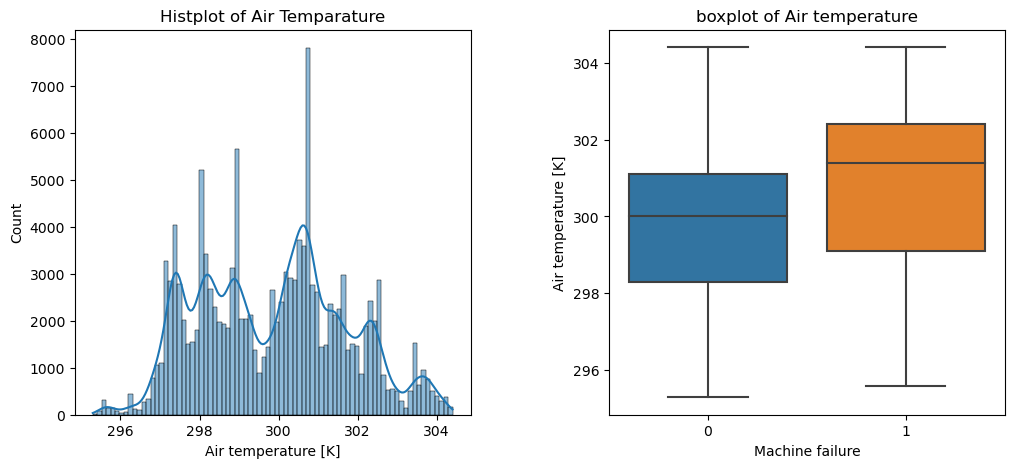

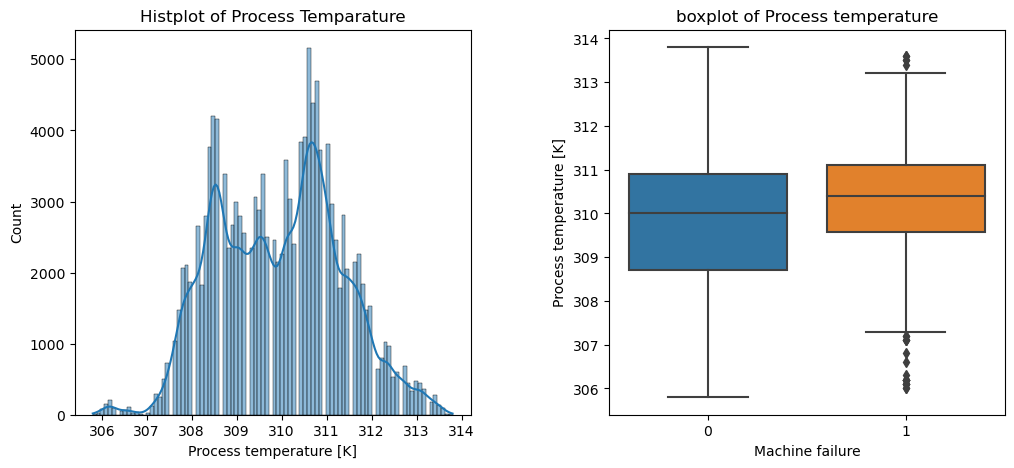

In [27]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(data['Air temperature [K]'], kde = True)
plt.title('Histplot of Air Temparature')

plt.subplot(1,2,2)
sns.boxplot(data= data, y = 'Air temperature [K]', x = 'Machine failure')
plt.title('boxplot of Air temperature')
plt.subplots_adjust(wspace=0.35)

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(data['Process temperature [K]'], kde = True)
plt.title('Histplot of Process Temparature')

plt.subplot(1,2,2)
sns.boxplot(data= data, y = 'Process temperature [K]', x = 'Machine failure')
plt.title('boxplot of Process temperature')
plt.subplots_adjust(wspace=0.35)

# 고장난 장비들은 특이하게 아랫쪽의 극단치만 존재했음

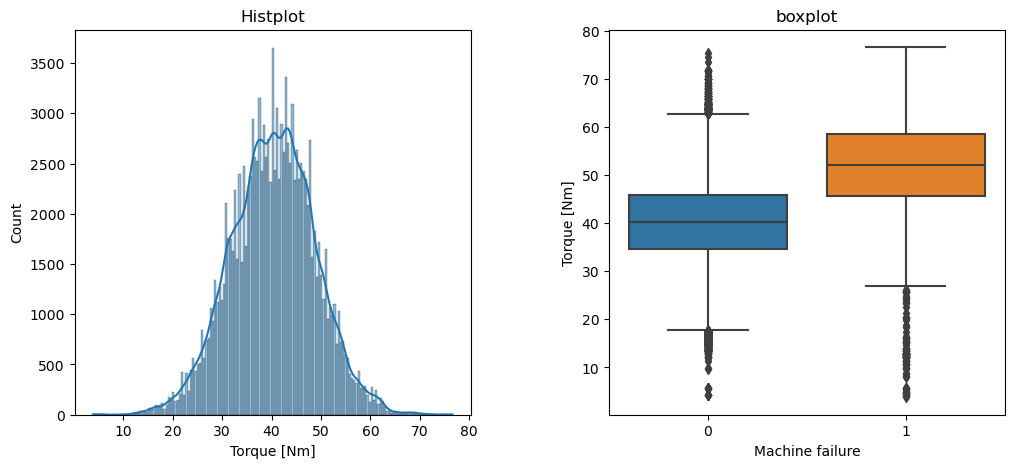

In [28]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(data['Torque [Nm]'], kde = True)
plt.title('Histplot')

plt.subplot(1,2,2)
sns.boxplot(data= data, y = 'Torque [Nm]', x = 'Machine failure')
plt.title('boxplot')
plt.subplots_adjust(wspace=0.35)

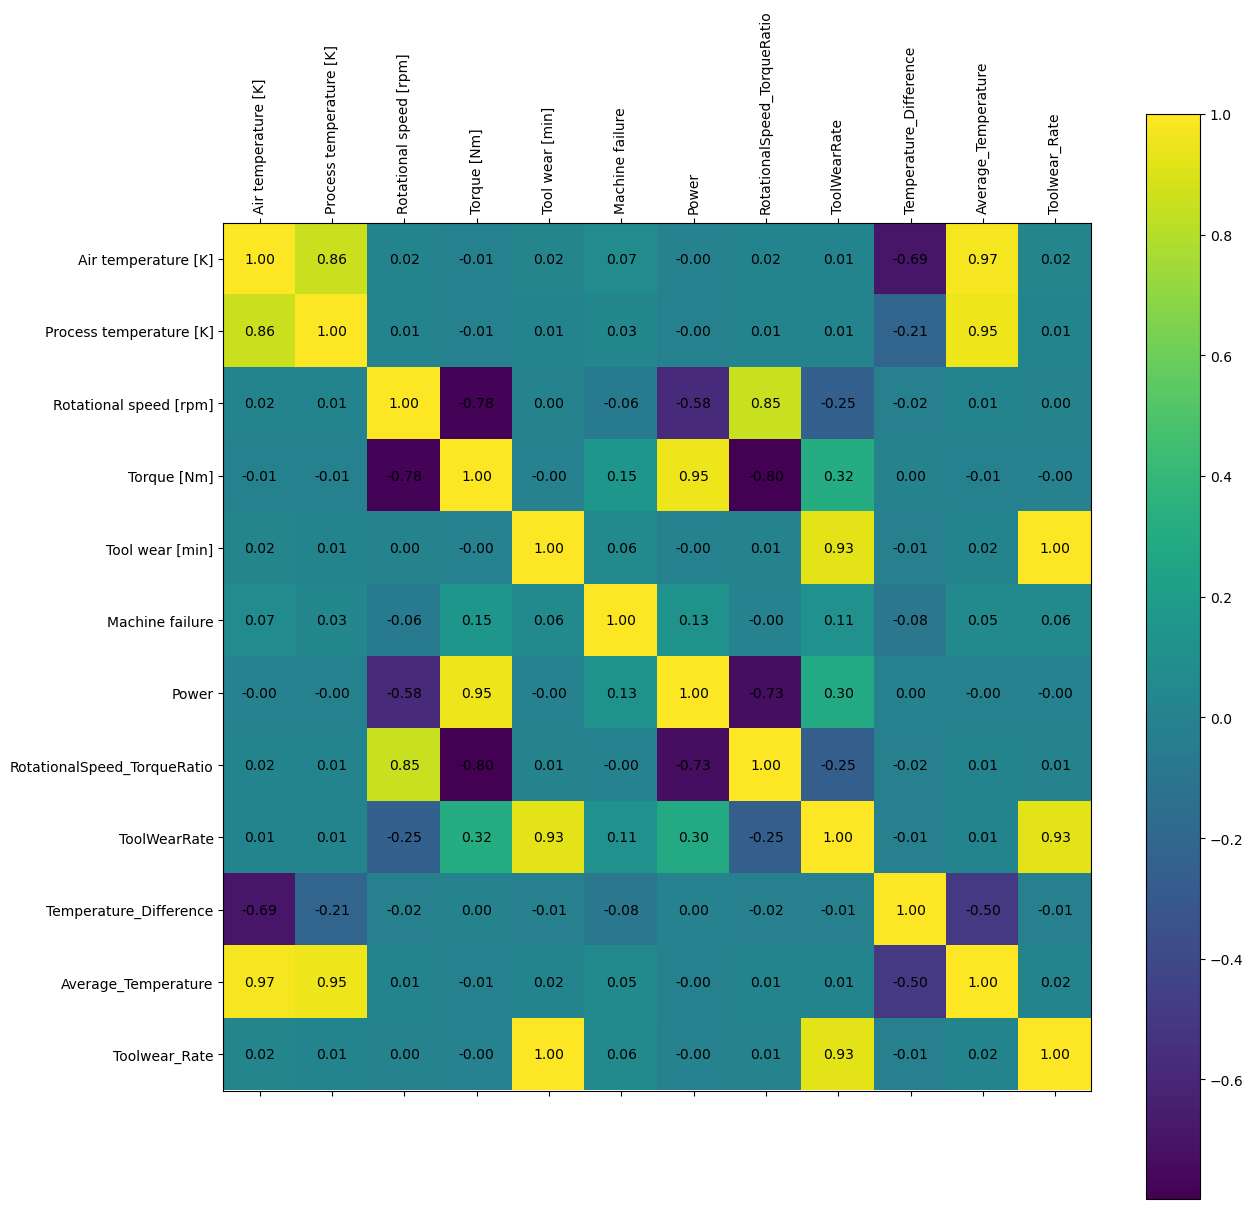

In [22]:
# 상관관계 메트릭스
correlation_matrix = data.drop(['Type'],axis=1).corr()

# 상관관계 메트릭스 시각화
plt.figure(figsize=(14, 14))

plt.matshow(correlation_matrix, fignum=1)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

for (i, j), val in np.ndenumerate(correlation_matrix):
    plt.text(j, i, '{:0.2f}'.format(val), ha='center', va='center', color='black')

plt.show()

In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X = renew_train.drop("Machine failure", axis=1)
y = renew_train["Machine failure"]

X_numeric = X.drop(['Type'],axis=1)
scaled_X_numeric = scaler.fit_transform(X_numeric)
X_num = pd.DataFrame(scaled_X_numeric)
X_num.columns = ['Air temperature','Process temperature','Rotational speed','Torque','Tool wear','Power','RotationalSpeed_TorqueRatio','ToolWear_Torque','Temperature_Difference','Average_Temperature','Toolwear_Rate']




encoder = OneHotEncoder(sparse=False)

encoded_X = encoder.fit_transform(X[['Type']])
tmp = pd.DataFrame(encoded_X, columns=['Type_'+ c for c in encoder.categories_[0]])


new_X = pd.concat([X_num,tmp],axis=1)
new_X

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Power,RotationalSpeed_TorqueRatio,ToolWear_Torque,Temperature_Difference,Average_Temperature,Toolwear_Rate,Type_H,Type_L,Type_M
0,-1.705246,-1.627005,-0.525035,0.986229,1.214560,0.955297,-0.354159,1.691494,1.072902,-1.744757,1.214560,0.0,1.0,0.0
1,0.844561,0.317652,-0.583527,0.423885,0.830644,0.225830,-0.288888,0.946727,-1.098174,0.660275,0.830644,0.0,1.0,0.0
2,0.094618,1.140392,-0.007600,1.093736,1.001273,1.576668,-0.322814,1.525791,1.159746,0.535338,1.001273,0.0,1.0,0.0
3,1.094542,0.168063,-0.538533,0.556201,0.219223,0.422647,-0.302863,0.418123,-1.706075,0.753978,0.219223,0.0,0.0,1.0
4,0.294603,1.439570,-0.687014,0.994499,0.702672,0.814759,-0.368827,1.138392,1.159746,0.785212,0.702672,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.194610,-0.430293,-0.610524,-0.097110,-1.216906,-0.419019,-0.207411,-1.074666,-0.837645,-0.058111,-1.216906,0.0,0.0,1.0
3996,1.794489,2.112720,-0.363055,-0.221156,1.072369,-0.396389,-0.155444,0.768192,-0.663959,2.003345,1.072369,0.0,1.0,0.0
3997,0.094618,0.242858,0.374853,-0.874467,1.555818,-0.794212,0.113259,0.671560,0.117629,0.160528,1.555818,0.0,0.0,1.0
3998,-0.705322,-1.103443,1.216247,-1.635285,-1.586603,-1.503696,0.633416,-1.420341,-0.056057,-0.901434,-1.586603,0.0,1.0,0.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=42)

X_train

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Power,RotationalSpeed_TorqueRatio,ToolWear_Torque,Temperature_Difference,Average_Temperature,Toolwear_Rate,Type_H,Type_L,Type_M
3994,-0.905307,-0.430293,-0.075091,0.101365,0.205004,0.221955,-0.186103,0.205596,1.072902,-0.745263,0.205004,0.0,1.0,0.0
423,0.594580,0.242858,5.180250,-2.743433,-1.387535,-2.453136,3.925996,-1.400211,-0.750802,0.472870,-1.387535,0.0,0.0,1.0
2991,-0.505337,-1.028649,0.721309,-1.056402,-0.193131,-0.864506,0.232540,-0.545655,-0.316586,-0.745263,-0.193131,0.0,0.0,1.0
1221,-0.155363,0.093269,-0.552031,-0.030952,1.214560,-0.297352,-0.213060,1.010778,0.378158,-0.058111,1.214560,0.0,0.0,1.0
506,-0.105367,-0.505087,-0.565530,1.374908,-1.088934,1.385774,-0.397236,-0.764421,-0.403429,-0.276751,-1.088934,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.944554,0.467241,-0.979478,1.904173,0.574700,1.564355,-0.471894,1.473215,-1.098174,0.785212,0.574700,0.0,1.0,0.0
1294,0.844561,0.242858,-0.583527,1.060657,0.532043,0.990386,-0.367196,0.986037,-1.185017,0.629041,0.532043,0.0,1.0,0.0
860,0.794565,0.616830,-0.309062,0.208871,-1.401754,0.180417,-0.228797,-1.209767,-0.663959,0.753978,-1.401754,0.0,0.0,1.0
3507,-1.055295,-1.402621,-0.358556,-0.353472,-0.818771,-0.558000,-0.126614,-0.791740,0.204472,-1.245010,-0.818771,0.0,1.0,0.0


# MLP

은닉층과 노드로 구성된 예측모델.
딥러닝의 기초모델이라고 볼 수 있다.

노드 베이스로 계산하기 때문에, 피쳐별 우선순위를 찾아낼 순 없다.

In [10]:
%%time
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import optuna
from sklearn.metrics import roc_auc_score, confusion_matrix

def MLP_objective(trial):
    MLP_model = MLPClassifier(
        hidden_layer_sizes=(trial.suggest_int('hidden_layer_sizes', 10, 200),),
        activation=trial.suggest_categorical('activation', ['identity', 'logistic', 'tanh', 'relu']),
        solver=trial.suggest_categorical('solver', ['lbfgs', 'sgd', 'adam']),
        alpha=trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        learning_rate_init=trial.suggest_float('learning_rate_init', 1e-5, 1e-1, log=True),
        max_iter=200,
        random_state=42
    )

    MLP_model.fit(X_train,y_train)

    
    y_pred_proba = MLP_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    return roc_auc

study = optuna.create_study(direction='maximize')
study.optimize(MLP_objective, n_trials=100)

print("Best trial:")
trial = study.best_trial
print("  Accuracy: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2024-05-08 11:47:54,226] A new study created in memory with name: no-name-3a858fc2-77fa-4e68-a428-bcb8d64f6a8b
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:47:56,785] Trial 0 finished with value: 0.9013453195917651 and parameters: {'hidden_layer_sizes': 89, 'activation': 'tanh', 'solver': 'sgd', 'alpha': 1.0678428445985077e-05, 'learning_rate_init': 0.0011971682376318937}. Best is trial 0 with value: 0.9013453195917651.
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:47:57,680] Trial 1 finished with value: 0.9298440281852604 and parameters: {'hidden_layer_sizes': 16, 'activation': 'log

[I 2024-05-08 11:48:27,560] Trial 16 finished with value: 0.9306715313824319 and parameters: {'hidden_layer_sizes': 119, 'activation': 'relu', 'solver': 'adam', 'alpha': 0.030414535352175927, 'learning_rate_init': 0.003235375398013819}. Best is trial 11 with value: 0.9351162265854209.
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:48:30,200] Trial 17 finished with value: 0.9076832418064645 and parameters: {'hidden_layer_sizes': 114, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.00030931787264848253, 'learning_rate_init': 0.0003733704786589654}. Best is trial 11 with value: 0.9351162265854209.
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization h

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:49:07,517] Trial 34 finished with value: 0.9347087439504502 and parameters: {'hidden_layer_sizes': 34, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.00057964397908529, 'learning_rate_init': 0.009100330010004147}. Best is trial 11 with value: 0.9351162265854209.
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:49:08,492] Trial 35 finished with value: 0.9342009578976403 and parameters: {'hidden_layer_sizes': 33, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.0001761118564317581, 'learning_rate_init': 0.007594460547129463}. Best is trial 11 

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:49:25,587] Trial 51 finished with value: 0.9364389779081722 and parameters: {'hidden_layer_sizes': 12, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.0008131615755615654, 'learning_rate_init': 0.019216158903634414}. Best is trial 51 with value: 0.9364389779081722.
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:49:26,414] Trial 52 finished with value: 0.9362634469269541 and parameters: {'hidden_layer_sizes': 12, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.0012589545129186443, 'learning_rate_init': 0.017757355628532808}. Best is trial 5

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:49:41,065] Trial 69 finished with value: 0.9279758770280097 and parameters: {'hidden_layer_sizes': 24, 'activation': 'tanh', 'solver': 'sgd', 'alpha': 0.007519620752959286, 'learning_rate_init': 0.006405193490183072}. Best is trial 51 with value: 0.9364389779081722.
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:49:41,885] Trial 70 finished with value: 0.8427117029012763 and parameters: {'hidden_layer_sizes': 44, 'activation': 'identity', 'solver': 'sgd', 'alpha': 0.0003920796411700487, 'learning_rate_init': 5.7089894017214136e-05}. Best is tr

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:50:04,835] Trial 87 finished with value: 0.9298064144035707 and parameters: {'hidden_layer_sizes': 29, 'activation': 'tanh', 'solver': 'sgd', 'alpha': 0.0008957301629884402, 'learning_rate_init': 0.08597920926074065}. Best is trial 71 with value: 0.9366082399257755.
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2024-05-08 11:50:06,514] Trial 88 finished with value: 0.9345959026053813 and parameters: {'hidden_layer_sizes': 61, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.0025403596018584015, 'learning_rate_init': 0.00877852396237579}. Best is trial 71 

Best trial:
  Accuracy: 0.9366207778530053
  Params: 
    hidden_layer_sizes: 11
    activation: relu
    solver: sgd
    alpha: 0.001505256776438145
    learning_rate_init: 0.019005498768244904
Wall time: 2min 19s


In [11]:
mlp_model = MLPClassifier(**study.best_params)
mlp_model.fit(X_train,y_train)

y_pred = mlp_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(accuracy)
print(conf_matrix)
print(report)

0.86375
[[339  39]
 [ 70 352]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       378
           1       0.90      0.83      0.87       422

    accuracy                           0.86       800
   macro avg       0.86      0.87      0.86       800
weighted avg       0.87      0.86      0.86       800



C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# LGBMClassifier

부스팅 기반의 트리 확장 학습 알고리즘이다. 기존 예측 트리를 새로운 확장트리에 일부반영해 발전시켜 나가는 형식으로 트리를 새로이 구성한다.

지금 새로 추가한 파라미터들이 공선성 이슈가 발생할 수 있기 때문에, 새로운 트리를 확장할 때, 잔차를 줄여나가며 학습하기 때문에, 변수간 상호작용을 잡아내기 용이할 수 있다.

찾아보니 랜덤포레스트 느낌의 트리류 분류모델이 무작위 서브셋을 사용해서 다중공선성의 영향을 덜 받는다고 함. 

## optuna로 최적의 파라미터 찾기

In [12]:
%%time
from lightgbm import LGBMClassifier


def lgbm_objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 900),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 1000),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
    }

    classifier = LGBMClassifier(**params, is_unbalance = True,metric = 'auc' )
    classifier.fit(X_train, y_train)
    y_pred_proba = classifier.predict_proba(X_test)[:, 1]

    # Calculate ROC AUC score for validation predictions
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    return roc_auc

study = optuna.create_study(direction='maximize')
study.optimize(lgbm_objective, n_trials=15)

# Print the best hyperparameters and corresponding ROC AUC score
lgbm_best_params = study.best_params
lgbm_best_score= study.best_value
print("Best Hyperparameters: ",lgbm_best_params)
print("Best ROC AUC Score: ", lgbm_best_score)

[I 2024-05-08 11:50:15,722] A new study created in memory with name: no-name-41b94297-1e3a-48ad-af06-745e0b9ba40b
<timed exec>:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
<timed exec>:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
<timed exec>:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
[I 2024-05-08 11:50:15,981] Trial 0 finished with value: 0.9243430126131547 and parameters: {'n_estimators': 338, 'learning_rate': 0.0015784319231273668, 'max_depth': 3, 'num_leaves': 202, 'subsample': 0.8074797709036228, 'colsample_bytree': 0.9872575613806

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1578, number of negative: 1622
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493125 -> initscore=-0.027502
[LightGBM] [Info] Start training from score -0.027502
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1578, number of negative: 1622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Nu

<timed exec>:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
<timed exec>:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
<timed exec>:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1578, number of negative: 1622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493125 -> initscore=-0.027502
[LightGBM] [Info] Start training from score -0.027502
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2024-05-08 11:50:24,558] Trial 14 finished with value: 0.9453659820958398 and parameters: {'n_estimators': 608, 'learning_rate': 0.024023416622373273, 'max_depth': 8, 'num_leaves': 348, 'subsample': 0.9939762939064389, 'colsample_bytree': 0.5189199886406598}. Best is trial 2 with value: 0.9461213922114396.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1578, number of negative: 1622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493125 -> initscore=-0.027502
[LightGBM] [Info] Start training from score -0.027502
0.87375
[[336  42]
 [ 59 363]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       378
           1       0.90      0.86      0.88       422

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800



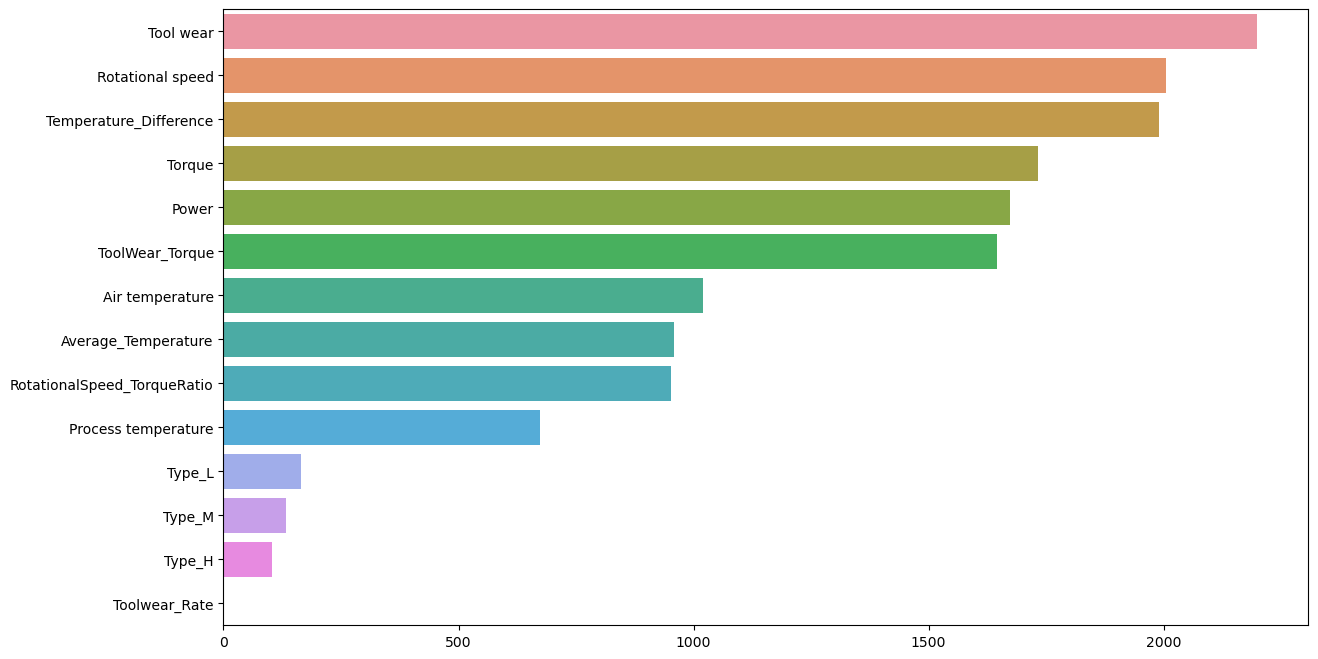

In [13]:
lgbm_model = LGBMClassifier(**lgbm_best_params, is_unbalance = True, metric = 'auc')
lgbm_model.fit(X_train,y_train)

y_pred = lgbm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(accuracy)
print(conf_matrix)
print(report)

plt.figure(figsize = (14, 8))
sns.barplot(y =X_train.columns, x =  lgbm_model.feature_importances_, 
            order=X_train.columns[np.argsort(-lgbm_model.feature_importances_)])
plt.show()

# KNN Cluster -> N=10 best

In [14]:
n_neighbors_group = [5, 10, 25, 50, 100, 200, 300, 500]
np.random.seed(1234)


for N in n_neighbors_group:
    knn = KNeighborsClassifier(n_neighbors=N)


    knn.fit(X_train, y_train)


    y_pred = knn.predict(X_test)


    # 성능 평가
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test,y_pred)
    print(f'n_neighbors : {N}일때 성능지표')
    print(accuracy)
    print(report)
    print(conf_matrix)
    
    print("\n\n")

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

n_neighbors : 5일때 성능지표
0.83125
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       378
           1       0.86      0.82      0.84       422

    accuracy                           0.83       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.83      0.83      0.83       800

[[321  57]
 [ 78 344]]



n_neighbors : 10일때 성능지표
0.8425
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       378
           1       0.91      0.78      0.84       422

    accuracy                           0.84       800
   macro avg       0.85      0.85      0.84       800
weighted avg       0.85      0.84      0.84       800

[[344  34]
 [ 92 330]]



n_neighbors : 25일때 성능지표
0.8375
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       378
           1       0.89      0.79      0.84       422

    accuracy                         

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

n_neighbors : 100일때 성능지표
0.8325
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       378
           1       0.90      0.77      0.83       422

    accuracy                           0.83       800
   macro avg       0.84      0.84      0.83       800
weighted avg       0.84      0.83      0.83       800

[[340  38]
 [ 96 326]]



n_neighbors : 200일때 성능지표
0.80875
              precision    recall  f1-score   support

           0       0.75      0.89      0.82       378
           1       0.89      0.73      0.80       422

    accuracy                           0.81       800
   macro avg       0.82      0.81      0.81       800
weighted avg       0.82      0.81      0.81       800

[[338  40]
 [113 309]]



n_neighbors : 300일때 성능지표
0.79875
              precision    recall  f1-score   support

           0       0.74      0.89      0.81       378
           1       0.88      0.72      0.79       422

    accuracy                    

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim